In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import polars as pl
import duckdb
import numpy as np
import torch
from einops import reduce
import lightning.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=4)

import conf.dataset
from conf import conf, downsampler as conf_downsamplers
from g_led import datasets, downsamplers, models, plots, utils

In [3]:
engine = conf.get_engine()
conf.orm.create_all(engine)
db = conf.sa.orm.Session(engine, expire_on_commit=False)
db.begin()

In [4]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

# Run sets

### Custom

Manually listed runs.

In [20]:
group_label = 'Custom'
special_variable = np.int64(0)
alt_id_runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label',
    ],
    data=[
        ['oocq2829', 'Lerp'],
        ['bzcw0ghk', 'Lerp ov'],
        ['90lwxavx', 'Gaus'],
        ['lshovu2w', 'Gaus ov'],
    ],
).with_columns(variable=pl.int_range(1, pl.len() + 1))

### Noised true forecast

Tests Imagen's sensitivity to noisy conditioning variables.
Noise is added to the macro states before they are upscaled using linear interpolation to compute the conditioning variables.
The macro states are computed using the true numerical trajectories.

In [11]:
group_label = 'Noised true forecast'
special_variable = 0.
alt_id_runs = duckdb.sql(r"""
select
    alt_id,
    format('$\sigma={:.2f}$', forecast_additive_noise_std) as label,
    forecast_additive_noise_std as variable
from Conf
join
    Macro
on Conf.Dataset = Macro.id
where
    Conf.Model
in (
    select
        Trained.id
    from
        Conf
    join
        Trained
    on Conf.Model = Trained.id
    where
        alt_id = 'nzgq1sx1'
)
and
    Macro.Trained is null
and
    Macro.Dataset
in (
    select
        Macro.Dataset
    from
        Conf
    join
        Macro
    on Conf.Dataset = Macro.id
    where
        alt_id = 'kpgmnhit'
)
;
""").pl()
alt_id_runs

alt_id,label,variable
str,str,f64
"""kpgmnhit""","""$\sigma=0.00$""",0.0
"""lfd5lab2""","""$\sigma=0.02$""",0.02
"""np8jpjrf""","""$\sigma=0.04$""",0.04
"""9x3kai9e""","""$\sigma=0.08$""",0.08
"""caddx3yf""","""$\sigma=0.16$""",0.16
"""hcwejdj4""","""$\sigma=0.32$""",0.32
"""amdnj4hf""","""$\sigma=0.64$""",0.64
"""8mlxfar5""","""$\sigma=1.28$""",1.28
"""2dikignw""","""$\sigma=2.56$""",2.56


### Noised true forecast (Overfit)

The noised true forecast where Imagen is only trained on the first 151 time steps.

In [18]:
group_label = 'Noised true forecast (Overfit)'
special_variable = 0.
alt_id_runs = duckdb.sql(r"""
select
    alt_id,
    format('$\sigma={:.2f}$', forecast_additive_noise_std) as label,
    forecast_additive_noise_std as variable
from Conf
join
    Macro
on Conf.Dataset = Macro.id
where
    Conf.Model
in (
    select
        Trained.id
    from
        Conf
    join
        Trained
    on Conf.Model = Trained.id
    where
        alt_id = 'oe5tfx2j'
)
and
    Macro.Trained is null
and
    Macro.Dataset
in (
    select
        Macro.Dataset
    from
        Conf
    join
        Macro
    on Conf.Dataset = Macro.id
    where
        alt_id = 'dl54uw04'
)
;
""").pl()
alt_id_runs

alt_id,label,variable
str,str,f64
"""dl54uw04""","""$\sigma=0.00$""",0.0
"""mvnrzhz8""","""$\sigma=0.02$""",0.02
"""6s4i7hmc""","""$\sigma=0.04$""",0.04
"""koo50knn""","""$\sigma=0.08$""",0.08
"""kqwukw7y""","""$\sigma=0.16$""",0.16
"""pghfwyqg""","""$\sigma=0.32$""",0.32
"""50p283j6""","""$\sigma=0.64$""",0.64
"""26amdkbj""","""$\sigma=1.28$""",1.28
"""mikfcxi1""","""$\sigma=2.56$""",2.56


### Noised forecast

Tests Imagen's sensitivity to noisy conditioning variables.
Noise is added to the macro states before they are upscaled using linear interpolation to compute the conditioning variables.
The macro states are forecasted using a transformer model.

In [14]:
group_label = 'Noised forecast'
special_variable = 0.
alt_id_runs = duckdb.sql(r"""
select
    alt_id,
    format('$\sigma={:.2f}$', forecast_additive_noise_std) as label,
    forecast_additive_noise_std as variable
from Conf
join
    Macro
on Conf.Dataset = Macro.id
where (
    Trained,
    Macro.Dataset
) in (
    select
        Trained,
        Macro.Dataset
    from
        Conf
    join
        Macro
    on Conf.Dataset = Macro.id
    where
        alt_id = 'nzgq1sx1'
)
;
""").pl()
alt_id_runs

alt_id,label,variable
str,str,f64
"""nzgq1sx1""","""$\sigma=0.00$""",0.0
"""1frahpts""","""$\sigma=0.02$""",0.02
"""b8yndifl""","""$\sigma=0.04$""",0.04
"""u9wurl6o""","""$\sigma=0.08$""",0.08
"""jzrpfxsh""","""$\sigma=0.16$""",0.16
"""k68bix3u""","""$\sigma=0.32$""",0.32
"""r8vq0x8w""","""$\sigma=0.64$""",0.64
"""xhzo4it5""","""$\sigma=1.28$""",1.28
"""etaouhjx""","""$\sigma=2.56$""",2.56


### Noised forecast (Overfit)

The noised forecast where Imagen is only trained on the first 151 time steps.

In [16]:
group_label = 'Noised forecast (Overfit)'
special_variable = 0.
alt_id_runs = duckdb.sql(r"""
select
    alt_id,
    format('$\sigma={:.2f}$', forecast_additive_noise_std) as label,
    forecast_additive_noise_std as variable
from Conf
join
    Macro
on Conf.Dataset = Macro.id
where (
    Trained,
    Macro.Dataset
) in (
    select
        Trained,
        Macro.Dataset
    from
        Conf
    join
        Macro
    on Conf.Dataset = Macro.id
    where
        alt_id = 'oe5tfx2j'
)
;
""").pl()
alt_id_runs

alt_id,label,variable
str,str,f64
"""oe5tfx2j""","""$\sigma=0.00$""",0.0
"""1ubdjujy""","""$\sigma=0.02$""",0.02
"""frhwi6lx""","""$\sigma=0.04$""",0.04
"""tg1db6oh""","""$\sigma=0.08$""",0.08
"""agpn5mzq""","""$\sigma=0.16$""",0.16
"""aewrkjhv""","""$\sigma=0.32$""",0.32
"""x1t4odgu""","""$\sigma=0.64$""",0.64
"""kqe7n8z6""","""$\sigma=1.28$""",1.28
"""0hyruglp""","""$\sigma=2.56$""",2.56


# Data loading

In [21]:
# special runs
TRUE_RUN = 'True'
# dynamic special runs (end in underscore)
CONDITIONING_UPSCALE_FORECAST_RUN = 'ConditioningUpscaleOfForecast'
special_runs = pl.DataFrame(
    orient='row',
    schema=[
        'id', 'label',
    ],
    data=[
        [TRUE_RUN, 'True'],
    ],
)
dynamic_special_runs = pl.DataFrame(
    orient='row',
    schema=['special', 'dynamic_id', 'dynamic_label'],
    data=[
        [True, CONDITIONING_UPSCALE_FORECAST_RUN, 'Fore.'],
        [False, '', ''],
    ],
)
runs = (
    alt_id_runs.join(dynamic_special_runs, how='cross')
    .select(
        pl.when('special').then('dynamic_id').otherwise('alt_id').alias('id'),
        pl.col('alt_id'),
        pl.when('special').then(pl.col('dynamic_label') + ' (' + pl.col('label') + ')').otherwise('label').alias('label'),
        pl.col('variable'),
        pl.col('special'),
    )
)
runs = (
    pl.concat([
        special_runs.select(
            pl.col('id'),
            pl.lit('').alias('alt_id'),
            pl.col('label'),
            pl.lit(special_variable).alias('variable').cast(pl.Int64),
            pl.lit(True).alias('special'),
        ),
        runs
    ])
    .with_columns(key=pl.int_range(pl.len()).cast(str))
)
def iter_runs(include_special=False, **kwargs):
    if 'named' not in kwargs:
        kwargs['named'] = True
    for row in runs.iter_rows(**kwargs):
        if include_special or not row['special']:
            yield row
runs

id,alt_id,label,variable,special,key
str,str,str,i64,bool,str
"""True""","""""","""True""",0,true,"""0"""
"""ConditioningUpscaleOfForecast""","""oocq2829""","""Fore. (Lerp)""",1,true,"""1"""
"""oocq2829""","""oocq2829""","""Lerp""",1,false,"""2"""
"""ConditioningUpscaleOfForecast""","""bzcw0ghk""","""Fore. (Lerp ov)""",2,true,"""3"""
"""bzcw0ghk""","""bzcw0ghk""","""Lerp ov""",2,false,"""4"""
"""ConditioningUpscaleOfForecast""","""90lwxavx""","""Fore. (Gaus)""",3,true,"""5"""
"""90lwxavx""","""90lwxavx""","""Gaus""",3,false,"""6"""
"""ConditioningUpscaleOfForecast""","""lshovu2w""","""Fore. (Gaus ov)""",4,true,"""7"""
"""lshovu2w""","""lshovu2w""","""Gaus ov""",4,false,"""8"""


In [22]:
cfgs = db.execute(conf.sa.select(conf.Conf).where(conf.Conf.alt_id.in_(runs.get_column('alt_id'))))
cfgs = {cfg.alt_id: {'cfg': cfg} for (cfg,) in cfgs}
context = defaultdict(dict)
for run in iter_runs():
    cfg = cfgs[run['alt_id']]['cfg']
    context[run['key']] = {'cfg': cfg}
    context[run['key']]['window_pred'] = torch.load(cfg.run_dir/'pred.pt')
    
    lightning.pytorch.seed_everything(cfg.rng_seed)
    with lightning.pytorch.utilities.seed.isolate_rng():
        dataset = datasets.get_dataset(cfg.dataset)
        dataset.prepare_data()
        dataset.setup('predict')
    downsampler = dataset.downsampler
    upsampler = downsamplers.get_upsampler(cfg.dataset.dataset)

    context[runs.filter(id=CONDITIONING_UPSCALE_FORECAST_RUN, alt_id=run['alt_id'])['key'][0]]['window_pred'] = upsampler(
        dataset.trajectories_macro[:, cfg.dataset.initial_sequence_time_step_count:]
    )
    
window = dataset.trajectories_micro[:, cfg.dataset.initial_sequence_time_step_count:]
context[runs.filter(id=TRUE_RUN)['key'][0]]['window_pred'] = window

max_key_len = runs.select(pl.col('key').str.len_chars().max())['key'][0]
for run in iter_runs(include_special=True):
    if run['key'] in context:
        print(f"{run['key']:<{max_key_len}}: {context[run['key']]['window_pred'].shape}")

Seed set to 2376999025
Seed set to 2376999025
Seed set to 2376999025
Seed set to 2376999025


0: torch.Size([1, 150, 2, 512, 512])
1: torch.Size([1, 150, 2, 512, 512])
2: torch.Size([1, 150, 2, 512, 512])
3: torch.Size([1, 150, 2, 512, 512])
4: torch.Size([1, 150, 2, 512, 512])
5: torch.Size([1, 150, 2, 512, 512])
6: torch.Size([1, 150, 2, 512, 512])
7: torch.Size([1, 150, 2, 512, 512])
8: torch.Size([1, 150, 2, 512, 512])


In [23]:
conf_downsamplers.DownsamplerLinearMode(len(cfg.dataset.dataset.dimensions())).name.lower()

'bilinear'

# Plots

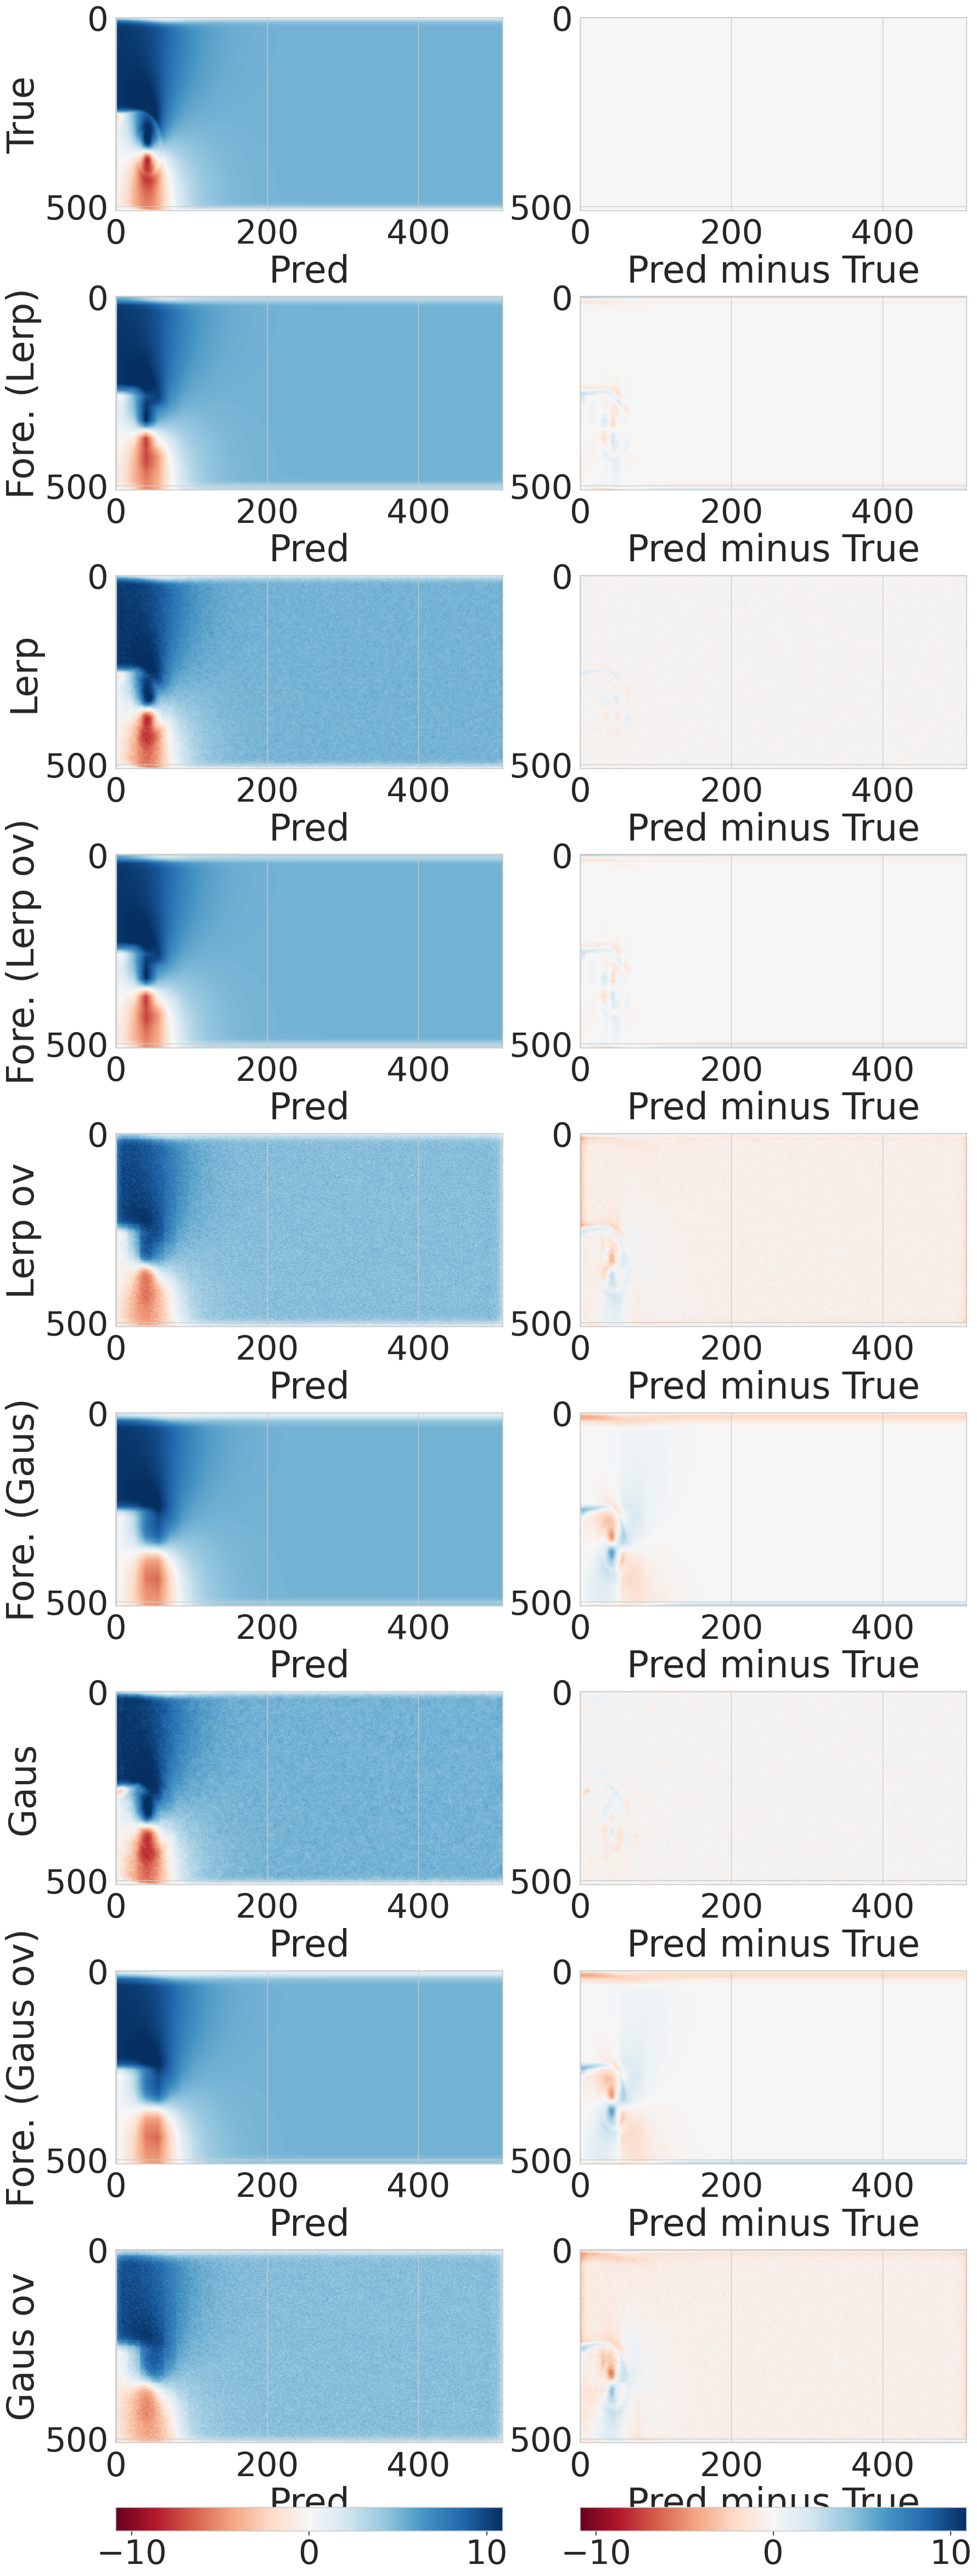

In [24]:
trajectory = 0
time_step = 1
component = 0

data_true = context[runs.filter(id=TRUE_RUN)['key'][0]]['window_pred'][trajectory, time_step, component]
p = .01
v_abs_max = max(np.quantile(data_true, p), np.quantile(data_true, 1 - p))

plot_context = {
    k: context[k]['window_pred'][trajectory, time_step, component]
    # for k in runs.get_column('key')
    for k in (
        runs
        # .filter((pl.col('id') == TRUE_RUN)|(pl.col('special') == True))
        .get_column('key')
    )
}
fig, axs = plt.subplots(figsize=(20, 6 + 6 * len(plot_context)), nrows=len(plot_context) + 1, ncols=2, height_ratios=[*([10] * len(plot_context)), 1])
for axs_row, (k, data) in zip(axs, plot_context.items()):
    im_out_pred = axs_row[0].imshow(data, cmap='RdBu', vmin=-v_abs_max, vmax=v_abs_max, aspect=0.5)
    run = runs.filter(key=k)
    axs_row[0].set_xlabel('Pred')
    axs_row[0].set_ylabel(run['label'][0])
    im_out_err = axs_row[1].imshow(data - data_true, cmap='RdBu', vmin=-v_abs_max, vmax=v_abs_max, aspect=0.5)
    axs_row[1].set_xlabel('Pred minus True')
fig.colorbar(im_out_pred, cax=axs[-1][0], orientation='horizontal')
fig.colorbar(im_out_err, cax=axs[-1][1], orientation='horizontal')
fig.savefig(f'MicroState.Component_{component}.TimeStep_{time_step}.pdf', format='pdf', bbox_inches='tight', pad_inches=.06)

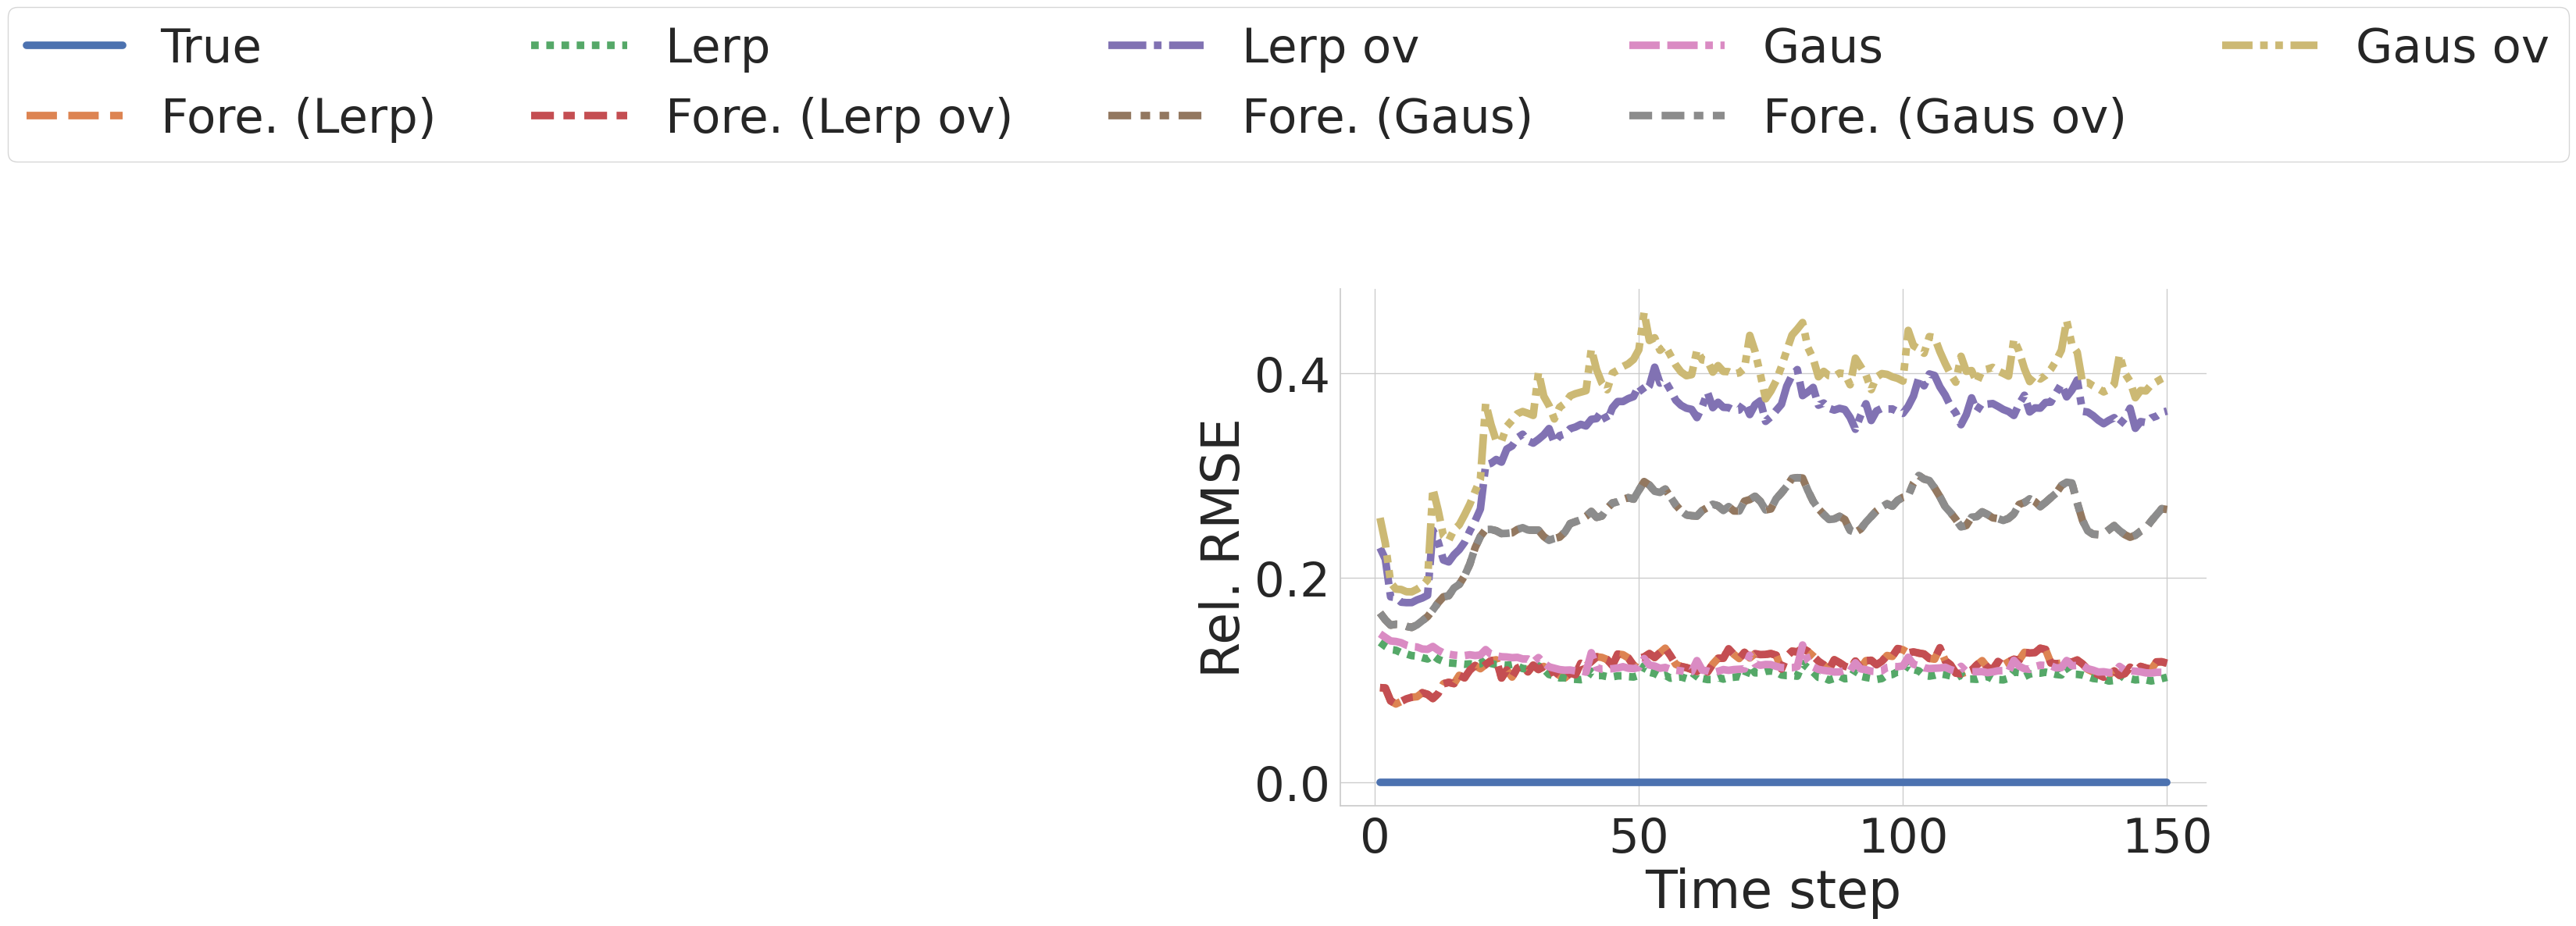

In [25]:
data_true = context[runs.filter(id=TRUE_RUN)['key'][0]]['window_pred']
rel_rmses = {}
for k, v in context.items():
    data = v['window_pred']
    rmse = reduce(
        (data - data_true).square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    norm = reduce(
        data_true.square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    rel_rmses[k] = (rmse / norm).mean(0).numpy()
rel_rmses = pl.DataFrame(rel_rmses).with_columns(window_time_step=pl.int_range(1, pl.len()+1))
# print(rel_rmses)
plot_runs = runs#.filter(special=False)
# plot_runs = runs.filter(pl.col('variable') < .5, special=False)
plot_data = (
    rel_rmses
    .unpivot(index='window_time_step', variable_name='key', value_name='error')
    .join(plot_runs, on='key')
)
# print(plot_data)
hue_style = 'key'
# hue_style = 'variable'
row_order = plot_runs.with_columns(key_int=pl.col('key').cast(int)).sort('key_int').get_column(hue_style)
plot_rmse = (
    sns.relplot(
        kind='line',
        data=plot_data,
        x='window_time_step',
        y='error',
        hue_order=row_order,
        style_order=row_order,
        hue=hue_style,
        style=hue_style,
        markers=data_true.shape[1] <= 100,
        linewidth=7,
        markersize=12,
        height=9.5,
        aspect=1.5,
        # palette=sns.cubehelix_palette(light=.8, n_colors=len(row_order)),
    )
    # .set(yscale='log')
    .set(
        xlabel='Time step',
        ylabel='Rel. RMSE',
        # xlim=(0, 80),
        # ylim=(.11, .25),
    )
)
sns.move_legend(
    plot_rmse,
    loc='right',
    labels=plot_runs['label'],
    ncol=min(5, len(row_order)),
    title='',
    # title=group_label,
    bbox_to_anchor=(1.13, 1.2),
    frameon=True,
    fancybox=True,
)

In [108]:
plots.save_all_subfigures(plot_rmse, 'RMSE', metadata_dataframe=plot_runs)